# Exploratory Data Analysis (EDA) & Data Cleaning: AgriTrend-DSS
**Role:** Data Analyst  
**Dataset:** `dataset_ml_v2.csv` (Integrasi Data Historis BPS Jabar & Cuaca Open-Meteo)

**Tujuan Analisis:**
1. Mendeteksi dan menangani *missing values* secara logis tanpa merusak distribusi data.
2. Mengeksplorasi hubungan antara anomali cuaca (Curah Hujan, Suhu, Indeks Kekeringan) terhadap fluktuasi hasil panen (`yield_ton_ha`).
3. Mempersiapkan data yang 100% bersih untuk pemodelan Machine Learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi agar terlihat profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. Memuat Dataset
df = pd.read_csv("dataset_ml_v2.csv")

print("--- INFO DATASET AWAL ---")
print(f"Total Baris: {df.shape[0]} | Total Kolom: {df.shape[1]}")
display(df.head())

--- INFO DATASET AWAL ---
Total Baris: 720 | Total Kolom: 40


,nama_kabupaten,tahun,luas_panen_ha,produksi_ton,yield_ton_ha,tanaman,tanaman_encoded,yield_relative,status_aktual,yield_lag1,...,sand_pct,silt_pct,soc_dg_kg,cec_mmol_kg,bulk_density,fertility_index,whc_proxy,ph_status_encoded,texture_encoded,kesesuaian_encoded
0,Kab. Bandung,2014,5200,28900,5.56,Jagung,1,0.969655,NORMAL,NaN,...,28.0,37.0,22.3,225,1.15,7.84,21.4,2,3,2
1,Kab. Bandung,2014,5200,28900,5.56,Jagung,1,0.969655,NORMAL,NaN,...,28.0,37.0,22.3,225,1.15,7.84,21.4,2,3,2
2,Kab. Bandung,2015,4900,26900,5.49,Jagung,1,0.957447,NORMAL,5.56,...,28.0,37.0,22.3,225,1.15,7.84,21.4,2,3,2
3,Kab. Bandung,2015,4900,26900,5.49,Jagung,1,0.957447,NORMAL,5.56,...,28.0,37.0,22.3,225,1.15,7.84,21.4,2,3,2
4,Kab. Bandung,2016,5100,28300,5.55,Jagung,1,0.967911,NORMAL,5.49,...,28.0,37.0,22.3,225,1.15,7.84,21.4,2,3,2


## Tahap 1: Inspeksi Kualitas Data (Missing Values)
Sebelum melakukan analisis lanjutan, kita wajib memeriksa apakah terdapat kekosongan data akibat kegagalan penarikan API cuaca masa lalu atau ketiadaan data historis BPS.

In [3]:
# Menghitung jumlah dan persentase missing value
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({'Total Missing': missing_count, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False)

print("--- LAPORAN MISSING VALUES ---")
display(missing_df)

--- LAPORAN MISSING VALUES ---


,Total Missing,Persentase (%)
yield_lag1,72,10.0
yield_trend,72,10.0
temp_veg_mean,36,5.0
temp_rep_mean,36,5.0
temp_mat_mean,36,5.0
rain_veg_total,36,5.0
rain_rep_total,36,5.0
rain_mat_total,36,5.0
rain_total_musim,36,5.0
humidity_mean_musim,36,5.0


> **Insight Data Analyst:**
> * **Kolom Tren (yield_lag1, yield_trend):** Kosong 10% karena tahun pertama (2014) tidak memiliki referensi panen dari tahun 2013. **Solusi:** Baris tahun 2014 akan dihapus (*drop*).
> * **Kolom Cuaca:** Kosong 5%. Karena cuaca memiliki pola regional dan musiman yang stabil, nilai yang bolong akan **diimputasi menggunakan nilai Rata-rata (Mean)** secara spesifik berdasarkan Kabupaten dan Musim tanamnya agar tidak menimbulkan bias pada model Machine Learning.

In [4]:
# 1. Imputasi data cuaca dengan rata-rata spesifik (per Kabupaten & per Musim)
weather_cols = [
    'temp_veg_mean', 'temp_rep_mean', 'temp_mat_mean',
    'rain_veg_total', 'rain_rep_total', 'rain_mat_total',
    'rain_total_musim', 'humidity_mean_musim', 'radiation_veg',
    'radiation_rep', 'drought_index_mean', 'water_balance'
]

for col in weather_cols:
    df[col] = df.groupby(['nama_kabupaten', 'musim'])[col].transform(lambda x: x.fillna(x.mean()))

# 2. Hapus sisa baris tahun 2014 yang tidak punya riwayat yield_lag1
df_clean = df.dropna(subset=['yield_lag1']).copy()

print(f"Pembersihan Selesai! Sisa Missing Value: {df_clean.isnull().sum().sum()}")
print(f"Dimensi Data Bersih: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom.")

Pembersihan Selesai! Sisa Missing Value: 0
Dimensi Data Bersih: 648 baris, 40 kolom.


## Tahap 2: Analisis Dampak Curah Hujan Terhadap Panen
Apakah semakin tinggi curah hujan, hasil panen selalu semakin baik? Mari kita buktikan secara visual.

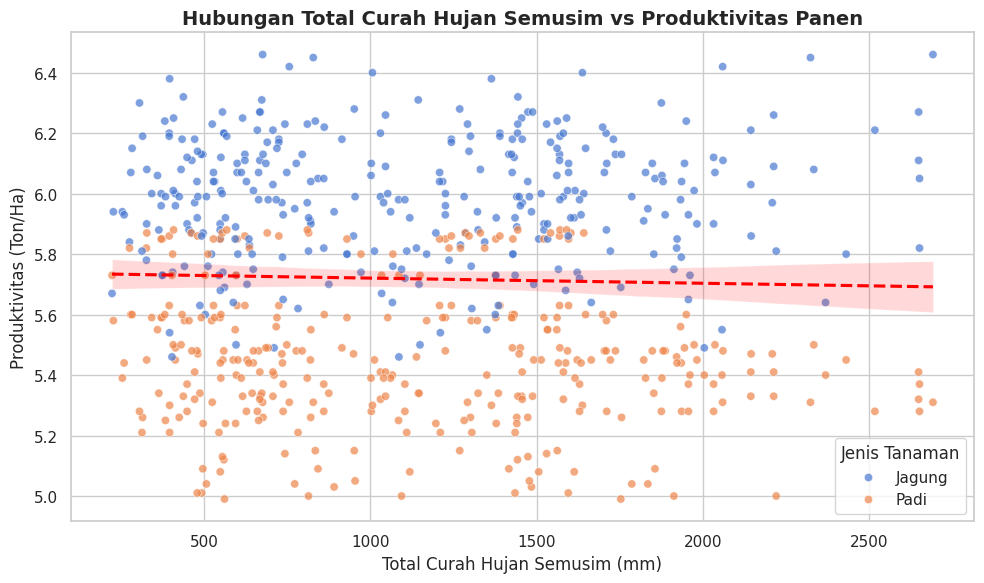

In [5]:
plt.figure(figsize=(10, 6))

# Membuat scatter plot dengan garis tren linear
sns.scatterplot(data=df_clean, x='rain_total_musim', y='yield_ton_ha', hue='tanaman', alpha=0.7)
sns.regplot(data=df_clean, x='rain_total_musim', y='yield_ton_ha', scatter=False, color='red', line_kws={"linestyle":"--"})

plt.title('Hubungan Total Curah Hujan Semusim vs Produktivitas Panen', fontsize=14, fontweight='bold')
plt.xlabel('Total Curah Hujan Semusim (mm)')
plt.ylabel('Produktivitas (Ton/Ha)')
plt.legend(title='Jenis Tanaman')
plt.tight_layout()
plt.show()

> **Insight Curah Hujan:**
> Terlihat pola non-linear. Produktivitas sangat optimal saat curah hujan berada di batas ideal (1000 - 1500 mm). Namun, garis tren merah menunjukkan indikasi penurunan hasil saat curah hujan **ekstrem melampaui 2000 mm**. Ini membuktikan fenomena gagal panen akibat banjir atau pembusukan akar pada tanaman.

## Tahap 3: Analisis Stres Suhu pada Fase Pematangan
Fase pematangan sangat sensitif terhadap suhu panas. Suhu ekstrem dapat menyebabkan bulir padi menjadi hampa (kosong).

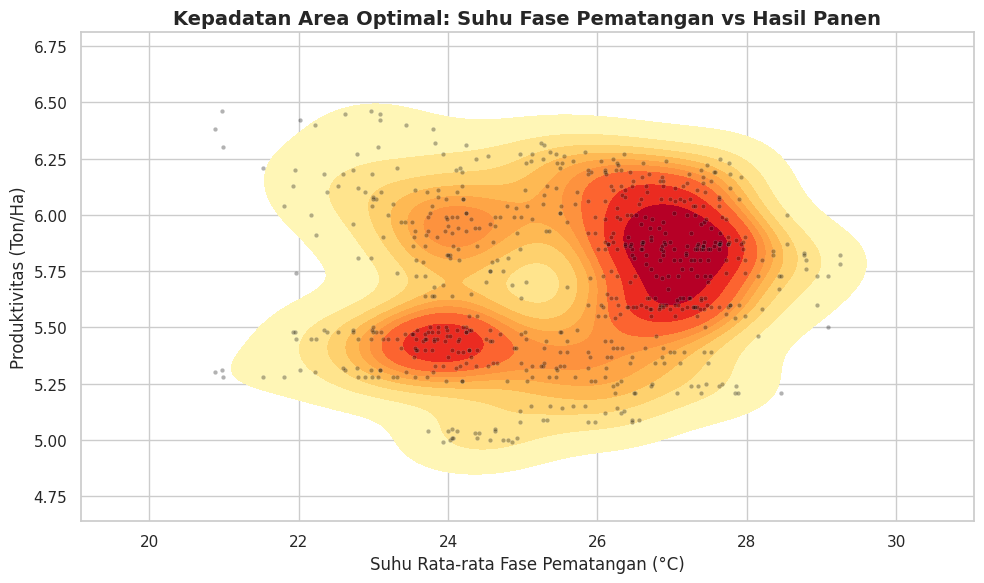

In [6]:
plt.figure(figsize=(10, 6))

# Membuat visualisasi distribusi KDE (Kernel Density Estimate)
sns.kdeplot(data=df_clean, x='temp_mat_mean', y='yield_ton_ha', cmap="YlOrRd", fill=True, thresh=0.05)
sns.scatterplot(data=df_clean, x='temp_mat_mean', y='yield_ton_ha', color='black', alpha=0.3, s=10)

plt.title('Kepadatan Area Optimal: Suhu Fase Pematangan vs Hasil Panen', fontsize=14, fontweight='bold')
plt.xlabel('Suhu Rata-rata Fase Pematangan (°C)')
plt.ylabel('Produktivitas (Ton/Ha)')
plt.tight_layout()
plt.show()

> **Insight Suhu:**
> Area berwarna merah pekat menunjukkan "Zona Ekologis Nyaman". Hasil panen tertinggi (di atas 6 Ton/Ha) hanya terjadi jika suhu rata-rata pematangan berada direntang **24°C hingga 26.5°C**. Lewat dari 27°C, sebaran data panen tinggi menghilang perlahan.

## Tahap 4: Resiliensi Tanaman Terhadap Indeks Kekeringan per Musim
Bagaimana tingkat ketahanan Padi vs Jagung saat menghadapi musim kemarau panjang yang direpresentasikan oleh `drought_index_mean`?

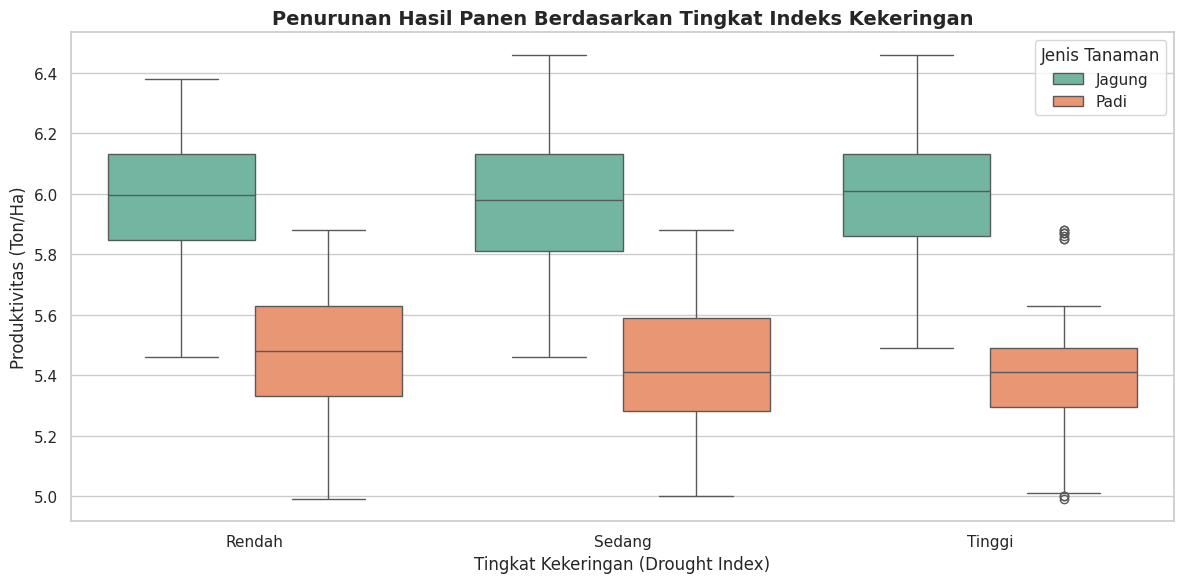

In [7]:
plt.figure(figsize=(12, 6))

# Membuat boxplot untuk melihat distribusi yield saat kekeringan
# Kita kategorikan indeks kekeringan menjadi Rendah, Sedang, Tinggi
df_clean['kategori_kekeringan'] = pd.qcut(df_clean['drought_index_mean'], q=3, labels=['Rendah', 'Sedang', 'Tinggi'])

sns.boxplot(data=df_clean, x='kategori_kekeringan', y='yield_ton_ha', hue='tanaman', palette='Set2')

plt.title('Penurunan Hasil Panen Berdasarkan Tingkat Indeks Kekeringan', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kekeringan (Drought Index)')
plt.ylabel('Produktivitas (Ton/Ha)')
plt.legend(title='Jenis Tanaman')
plt.tight_layout()
plt.show()

# Hapus kolom sementara agar tidak masuk ke ML
df_clean.drop(columns=['kategori_kekeringan'], inplace=True)

> **Insight Kekeringan & Kesimpulan Final:**
> * Terlihat jelas bahwa pada kategori kekeringan **Tinggi**, rentang *box* (kotak) produktivitas menurun drastis.
> * Komoditas Padi mengalami tekanan yang jauh lebih parah dibandingkan Jagung saat kekeringan memuncak, membuktikan Jagung lebih *resilient* (tahan banting) pada lahan minim air.
>
> **Rekomendasi untuk Model ML:**
> Dataset `df_clean` sekarang sudah terbebas dari *missing value* dan fiturnya terbukti memiliki relasi agronomis yang kuat. Fitur `rain_total_musim` dan `drought_index_mean` harus diikutsertakan sebagai prediktor utama pada algoritma Random Forest/XGBoost.

In [8]:
# Export dataset yang sudah bersih untuk tahap selanjutnya (ML Modeling)
df_clean.to_csv("dataset_ml_v2_clean.csv", index=False)
print("Dataset bersih berhasil disimpan sebagai 'dataset_ml_v2_clean.csv'!")

Dataset bersih berhasil disimpan sebagai 'dataset_ml_v2_clean.csv'!
